# Content:
   - [Loading The Dataset](#1)
   - [Normalization, Reshape and Label Encoding](#2)
   - [Train Test Split](#3)
   - [Convolutional Neural Network](#4)
   - [Submission](#5)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


<a id="1"></a>
# Loading The Dataset

In [2]:
# read train
train = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
# read test
test = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

In [3]:
# shape
print("Train shape: ",train.shape)
print("Test shape: ",test.shape)

Train shape:  (42000, 785)
Test shape:  (28000, 784)


In [4]:
train.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
test.head(10)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# drop label column
x_train = train.drop("label", axis = 1)
# put labels into y_train variable 
y_train = train["label"]

In [7]:
# value count number of digits classes
y_train.value_counts()

1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: label, dtype: int64

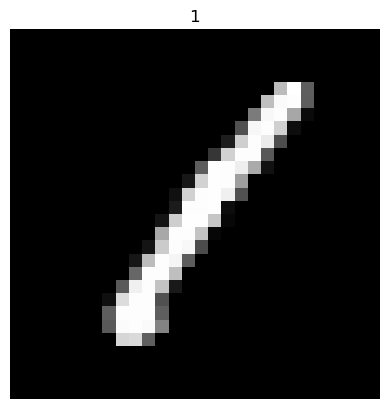

In [8]:
# plot some samples
img = np.asmatrix(x_train.iloc[0].values).reshape((28,28))
plt.imshow(img,cmap='gray')
plt.title(train.iloc[0,0])
plt.axis("off")
plt.show()

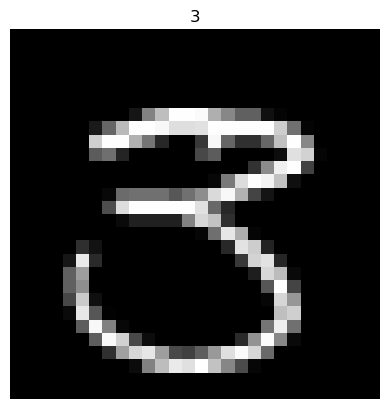

In [9]:
# plot some samples
img = np.asmatrix(x_train.iloc[7].values).reshape((28,28))
plt.imshow(img, cmap = "gray")
plt.title(train.iloc[7,0])
plt.axis("off")
plt.show()

<a id="2"></a>
# Normalization, Reshape and Label Encoding

In [10]:
# Normalize the data 
x_train = x_train / 255.0
test = test / 255.0
print("x_train shape: ", x_train.shape)
print("test shape: ", test.shape)

x_train shape:  (42000, 784)
test shape:  (28000, 784)


In [11]:
# Reshape
x_train = x_train.values.reshape(-1,28,28,1)
test = test.values.reshape(-1,28,28,1)
print("x_train shape: ", x_train.shape)
print("test shape: ", test.shape)

x_train shape:  (42000, 28, 28, 1)
test shape:  (28000, 28, 28, 1)


In [12]:
# Label Encoding 
from keras.utils.np_utils import to_categorical # convertto one-hot-encoding 
y_train = to_categorical(y_train, num_classes=10)

<a id="3"></a>
# Train Test Split

In [13]:
# split the train and the validation set for the fitting 
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=2)

print("x_train shape: ", x_train.shape)
print("x_val shape: ", x_val.shape)
print("y_train shape: ", y_train.shape)
print("y_val shape: ", y_val.shape)

x_train shape:  (37800, 28, 28, 1)
x_val shape:  (4200, 28, 28, 1)
y_train shape:  (37800, 10)
y_val shape:  (4200, 10)


<a id="4"></a>
# Convolutional Neural Network

In [14]:
from sklearn.metrics import confusion_matrix
import itertools
from keras.utils.np_utils import to_categorical 
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import RMSprop, Adam
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau

In [15]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = "Same", activation="relu", input_shape = (28,28,1)))
model.add(MaxPool2D(pool_size= (2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters = 32, kernel_size = (3,3), padding="Same", activation="relu"))
model.add(MaxPool2D(pool_size= (2,2)))
model.add(Dropout(0.25))

# fully connected
model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation="softmax"))

In [16]:
# Define the optimizer
optimizer = Adam(lr = 0.001, beta_1 = 0.9, beta_2 = 0.999)

/opt/conda/lib/python3.7/site-packages/keras/optimizers/optimizer_v2/adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [17]:
model.compile(optimizer=optimizer, loss = "categorical_crossentropy", metrics = ["accuracy"])

In [18]:
# Epochs and Batch Size
epochs = 40    # for better result increase the epochs
batch_size = 64

In [19]:
# data augmentation
datagen = ImageDataGenerator(
    featurewise_center=False,  # set input mean to 0 over the dataset
    samplewise_center=False,   # set each sample mean to 0
    featurewise_std_normalization=False,   # divide inputs by std of the dataset
    samplewise_std_normalization= False,   # divide each input by its std
    zca_whitening=False,   # dimesion reduction
    rotation_range=5,    # randomly rotate images in the range 5 degrees
    zoom_range=0.1,      # Randomly zoom image 10%
    width_shift_range=0.1,   # randomly shift images horizontally 10%
    height_shift_range=0.1,   # randomly shift images vertically 10%
    horizontal_flip=False,     # randomly flip images
    vertical_flip=False    # randomly flip images
)  

datagen.fit(x_train)

In [20]:
# Fit the model
history = model.fit_generator(datagen.flow(x_train,y_train, batch_size=batch_size),
                              epochs = epochs, validation_data = (x_val,y_val), steps_per_epoch=x_train.shape[0] // batch_size)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  This is separate from the ipykernel package so we can avoid doing imports until


Epoch 1/40
590/590 [==============================] - 22s 35ms/step - loss: 0.6860 - accuracy: 0.7712 - val_loss: 0.1031 - val_accuracy: 0.9681
Epoch 2/40
590/590 [==============================] - 21s 35ms/step - loss: 0.2416 - accuracy: 0.9266 - val_loss: 0.0777 - val_accuracy: 0.9764
Epoch 3/40
590/590 [==============================] - 20s 35ms/step - loss: 0.1895 - accuracy: 0.9431 - val_loss: 0.0536 - val_accuracy: 0.9840
Epoch 4/40
590/590 [==============================] - 20s 35ms/step - loss: 0.1581 - accuracy: 0.9530 - val_loss: 0.0533 - val_accuracy: 0.9862
Epoch 5/40
590/590 [==============================] - 20s 35ms/step - loss: 0.1390 - accuracy: 0.9590 - val_loss: 0.0538 - val_accuracy: 0.9840
Epoch 6/40
590/590 [==============================] - 20s 34ms/step - loss: 0.1287 - accuracy: 0.9612 - val_loss: 0.0446 - val_accuracy: 0.9881
Epoch 7/40
590/590 [==============================] - 20s 35ms/step - loss: 0.1185 - accuracy: 0.9648 - val_loss: 0.0555 - val_accuracy:

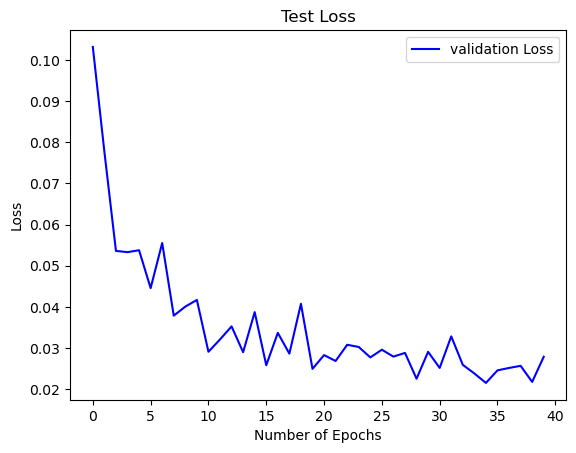

In [21]:
# plot the loss and accuracy curves for training and validation 
plt.plot(history.history["val_loss"], color = "b", label = "validation Loss")
plt.title("Test Loss")
plt.xlabel("Number of Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

<a id="5"></a>
# Submission

In [22]:
# predict results
results = model.predict(test)

# select the indix with the maximum probability
results = np.argmax(results, axis = 1)
results = pd.Series(results, name = "Label")


875/875 [==============================] - 5s 5ms/step


In [23]:
submission = pd.concat([pd.Series(range(1,28001), name ="ImageId"), results], axis = 1)

In [24]:
submission.to_csv("cnn_digit_submission.csv", index  =False)

In [25]:
submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3
